<a href="https://colab.research.google.com/github/padminidokka/AI-Based-Dental-Radiograph-Analysis-System/blob/main/Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install segment-anything
!pip install opencv-python matplotlib
!pip install torch torchvision


In [ ]:
!wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

--2026-03-06 03:24:41--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 3.163.189.51, 3.163.189.108, 3.163.189.14, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|3.163.189.51|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 375042383 (358M) [binary/octet-stream]
Saving to: ‘sam_vit_b_01ec64.pth’

sam_vit_b_01ec64.pt 100%[===================>] 357.67M   244MB/s    in 1.5s    

2026-03-06 03:24:43 (244 MB/s) - ‘sam_vit_b_01ec64.pth’ saved [375042383/375042383]



In [ ]:
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator
import cv2
import matplotlib.pyplot as plt

sam = sam_model_registry["vit_b"](checkpoint="sam_vit_b_01ec64.pth")
mask_generator = SamAutomaticMaskGenerator(sam)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


(np.float64(-0.5), np.float64(1023.5), np.float64(511.5), np.float64(-0.5))

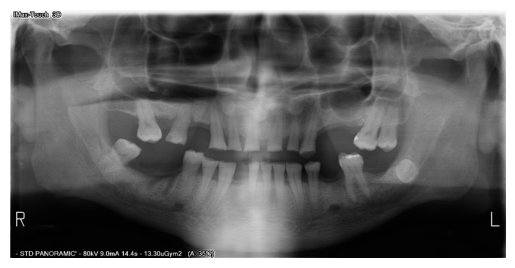

In [ ]:
import cv2
import matplotlib.pyplot as plt

image_path = "/content/drive/MyDrive/Dental/opg_images/1.jpg"

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Resize image (VERY IMPORTANT)
image = cv2.resize(image, (1024, 512))

plt.imshow(image)
plt.axis("off")

In [ ]:
mask_generator = SamAutomaticMaskGenerator(
    sam,
    points_per_side=128,
    points_per_batch=256,
    pred_iou_thresh=0.96,
    stability_score_thresh=0.98,
    crop_n_layers=2,
    crop_n_points_downscale_factor=2,
    min_mask_region_area=300
)

In [ ]:
masks = mask_generator.generate(image)

print(len(masks))

In [ ]:
img = cv2.imread("opg.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
enhanced = clahe.apply(gray)
image = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB)

(np.float64(-0.5), np.float64(1023.5), np.float64(511.5), np.float64(-0.5))

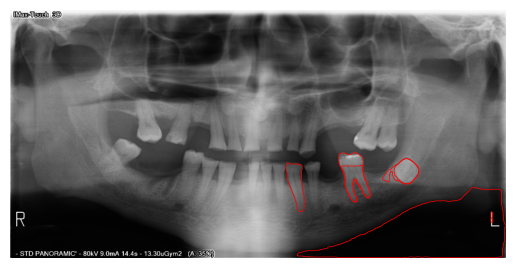

In [ ]:
import numpy as np

plt.imshow(image)

for mask in masks:
    m = mask["segmentation"]
    plt.contour(m, colors="red", linewidths=0.5)

plt.axis("off")

In [ ]:
mask_image = np.zeros(image.shape[:2], dtype=np.uint8)

for i, mask in enumerate(masks):
    mask_image[mask["segmentation"]] = i + 1

(np.float64(-0.5), np.float64(1023.5), np.float64(511.5), np.float64(-0.5))

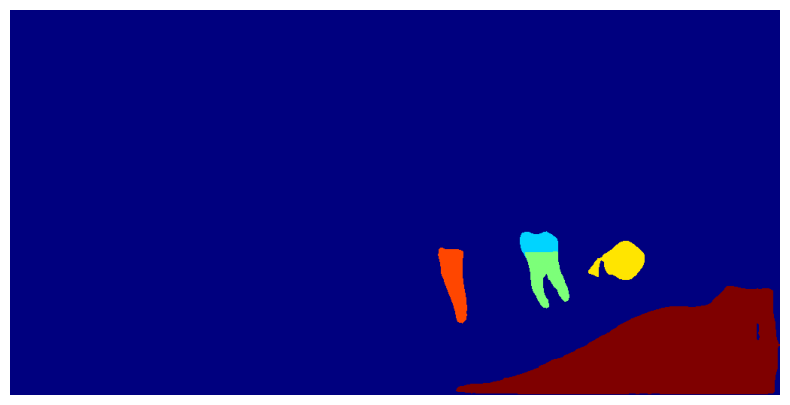

In [ ]:
plt.figure(figsize=(10,5))
plt.imshow(mask_image, cmap="jet")
plt.axis("off")

In [ ]:
import os

os.makedirs("/content/drive/MyDrive/Dental/masks", exist_ok=True)

In [ ]:
import os
print(os.listdir("/content/drive/MyDrive/Dental/masks"))

['114_mask.png', '111_mask.png', '118_mask.png', '121_mask.png', '125_mask.png', '11_mask.png', '113_mask.png', '104_mask.png', '107_mask.png', '10_mask.png', '102_mask.png', '129_mask.png', '126_mask.png', '119_mask.png', '109_mask.png', '124_mask.png', '103_mask.png', '122_mask.png', '128_mask.png', '1_mask.png', '100_mask.png', '101_mask.png', '105_mask.png', '106_mask.png', '108_mask.png', '110_mask.png', '112_mask.png', '115_mask.png', '116_mask.png', '117_mask.png', '12_mask.png', '120_mask.png', '123_mask.png', '127_mask.png', '13_mask.png', '130_mask.png', '131_mask.png', '132_mask.png', '133_mask.png', '134_mask.png', '135_mask.png', '136_mask.png', '137_mask.png', '138_mask.png', '139_mask.png', '14_mask.png', '140_mask.png', '141_mask.png', '142_mask.png', '143_mask.png', '144_mask.png', '145_mask.png', '146_mask.png', '147_mask.png', '148_mask.png', '149_mask.png', '15_mask.png', '150_mask.png', '151_mask.png', '152_mask.png', '153_mask.png', '154_mask.png', '155_mask.png',

In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm
import torch

input_folder = "/content/drive/MyDrive/Dental/opg_images"
output_folder = "/content/drive/MyDrive/Dental/masks"

os.makedirs(output_folder, exist_ok=True)

# only image files
files = sorted([f for f in os.listdir(input_folder) if f.lower().endswith((".jpg",".png",".jpeg"))])

# LIMIT NUMBER OF IMAGES (for faster testing)
MAX_IMAGES = 10
files = files[:MAX_IMAGES]

batch_size = 7

print("Total images being processed:", len(files))

# ensure SAM runs on GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
sam.to(device=device)

print("Using device:", device)

for batch_start in range(0, len(files), batch_size):

    batch_files = files[batch_start: batch_start + batch_size]

    print(f"\nProcessing Batch {batch_start//batch_size + 1}")

    for file in tqdm(batch_files):

        save_name = file.split(".")[0] + "_mask.png"
        save_path = os.path.join(output_folder, save_name)

        # skip already processed images
        if os.path.exists(save_path):
            continue

        image_path = os.path.join(input_folder, file)

        image = cv2.imread(image_path)

        # SMALLER IMAGE = MUCH FASTER
        image = cv2.resize(image, (256,128))

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # generate SAM masks
        masks = mask_generator.generate(image)

        mask_image = np.zeros(image.shape[:2], dtype=np.uint8)

        # limit masks heavily
        for i, mask in enumerate(masks[:5]):
            mask_image[mask["segmentation"]] = i + 1

        cv2.imwrite(save_path, mask_image)

    print(f"Batch {batch_start//batch_size + 1} completed")

print("\nAll masks generated successfully.")

Total images being processed: 10
Using device: cpu

Processing Batch 1


100%|██████████| 7/7 [00:00<00:00, 2462.68it/s]


Batch 1 completed

Processing Batch 2


100%|██████████| 3/3 [00:00<00:00, 1228.92it/s]

Batch 2 completed

All masks generated successfully.
